In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from model import GPTConfig
from hooked_model import HookedGPT

In [6]:
CKPT_PATH = 'out/ckpt.pt'
D_IN = 64      
D_HIDDEN = 512 
L1_COEFF = 1e-3
LR = 3e-4
BATCH_SIZE = 256
NUM_EPOCHS = 20
SEQ_LEN = 32
DEVICE = 'mps'

ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
config = GPTConfig(**ckpt['model_args'])
model = HookedGPT(config)
model.load_state_dict(ckpt['model'])
model.eval()
model.to(DEVICE)


number of parameters: 3.27M


HookedGPT(
  (transformer): ModuleDict(
    (wte): Embedding(50304, 64)
    (wpe): Embedding(32, 64)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0): Block(
        (ln_1): LayerNorm()
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=64, out_features=192, bias=False)
          (c_proj): Linear(in_features=64, out_features=64, bias=False)
          (attn_dropout): Dropout(p=0.0, inplace=False)
          (resid_dropout): Dropout(p=0.0, inplace=False)
        )
        (ln_2): LayerNorm()
        (mlp): MLP(
          (c_fc): Linear(in_features=64, out_features=256, bias=False)
          (gelu): GELU(approximate='none')
          (c_proj): Linear(in_features=256, out_features=64, bias=False)
          (dropout): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm()
  )
  (lm_head): Linear(in_features=64, out_features=50304, bias=False)
)

In [8]:
def collect_activations(model, n_batches=100):
    all_acts = []
    
    for _ in range(n_batches):
        captured = []
        
        def hook_fn(module, input, output):
            act = output[0] if isinstance(output, tuple) else output
            captured.append(act.clone().detach())
        
        handle = model.transformer.h[-1].register_forward_hook(hook_fn)
        
        idx = torch.randint(0, config.vocab_size, (BATCH_SIZE, SEQ_LEN)).to(DEVICE)
        with torch.no_grad():
            model(idx) 
        
        handle.remove()
        
        acts = torch.cat(captured, dim=0)  
        acts = acts.reshape(-1, D_IN)
        all_acts.append(acts.cpu())
    
    return torch.cat(all_acts, dim=0)

In [9]:
print("Collecting activations...")
activations = collect_activations(model, n_batches=100)
print(f"Activation dataset shape: {activations.shape}")

dataset = TensorDataset(activations)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

Activation dataset shape: torch.Size([819200, 64])


In [10]:
class SAE(nn.Module):
    def __init__(self, d_in=D_IN, d_hidden=D_HIDDEN, l1_coeff=L1_COEFF):
        super().__init__()
        self.W_enc = nn.Linear(d_in, d_hidden)
        self.W_dec = nn.Linear(d_hidden, d_in)
        self.l1_coeff = l1_coeff

        
        self.W_dec.weight.data = F.normalize(self.W_dec.weight.data, dim=0)

    def encode(self, x):
        return F.relu(self.W_enc(x))  

    def decode(self, features):
        return self.W_dec(features) 

    def forward(self, x):
        features = self.encode(x)
        recon = self.decode(features)

        l2_loss = (recon - x).pow(2).mean()
        l1_loss = self.l1_coeff * features.abs().mean()
        loss = l2_loss + l1_loss

        return recon, features, l2_loss, l1_loss

In [11]:
sae = SAE().to(DEVICE)
optimizer = torch.optim.Adam(sae.parameters(), lr=LR)

print("Training SAE...")
for epoch in range(NUM_EPOCHS):
    total_loss = 0
    for (batch,) in dataloader:
        batch = batch.to(DEVICE)

        recon, features, l2_loss, l1_loss = sae(batch)
        loss = l2_loss + l1_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        sae.W_dec.weight.data = F.normalize(sae.W_dec.weight.data, dim=0)

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | loss: {avg_loss:.9f} | l2: {l2_loss:.9f} | l1: {l1_loss:.9f}")

Training SAE...


/Users/sahitidoke/Downloads/monosemantic/.venv/lib/python3.9/site-packages/torch/autograd/__init__.py:251: UserWarning: The operator 'aten::sgn.out' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:13.)
  Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1/20 | loss: 0.000398012 | l2: 0.000008313 | l1: 0.000040219
Epoch 2/20 | loss: 0.000035771 | l2: 0.000003436 | l1: 0.000022901
Epoch 3/20 | loss: 0.000022180 | l2: 0.000002698 | l1: 0.000016651
Epoch 4/20 | loss: 0.000017493 | l2: 0.000002069 | l1: 0.000013990
Epoch 5/20 | loss: 0.000015172 | l2: 0.000002189 | l1: 0.000012244
Epoch 6/20 | loss: 0.000013575 | l2: 0.000001907 | l1: 0.000011205
Epoch 7/20 | loss: 0.000012388 | l2: 0.000001647 | l1: 0.000010382
Epoch 8/20 | loss: 0.000011480 | l2: 0.000001823 | l1: 0.000009447
Epoch 9/20 | loss: 0.000010746 | l2: 0.000001652 | l1: 0.000009215
Epoch 10/20 | loss: 0.000010118 | l2: 0.000001216 | l1: 0.000008540
Epoch 11/20 | loss: 0.000009583 | l2: 0.000001073 | l1: 0.000008234
Epoch 12/20 | loss: 0.000009131 | l2: 0.000001133 | l1: 0.000007623
Epoch 13/20 | loss: 0.000008723 | l2: 0.000001141 | l1: 0.000007542
Epoch 14/20 | loss: 0.000008362 | l2: 0.000000905 | l1: 0.000007102
Epoch 15/20 | loss: 0.000008017 | l2: 0.000000959 | l1: 0

In [13]:
torch.save(sae.state_dict(), 'out/sae_ckpt.pt')
print("SAE saved to out/sae_ckpt.pt")

SAE saved to out/sae_ckpt.pt


Text(0.5, -0.02, 'Total features: 512 | Dead: 186 | Active: 326')

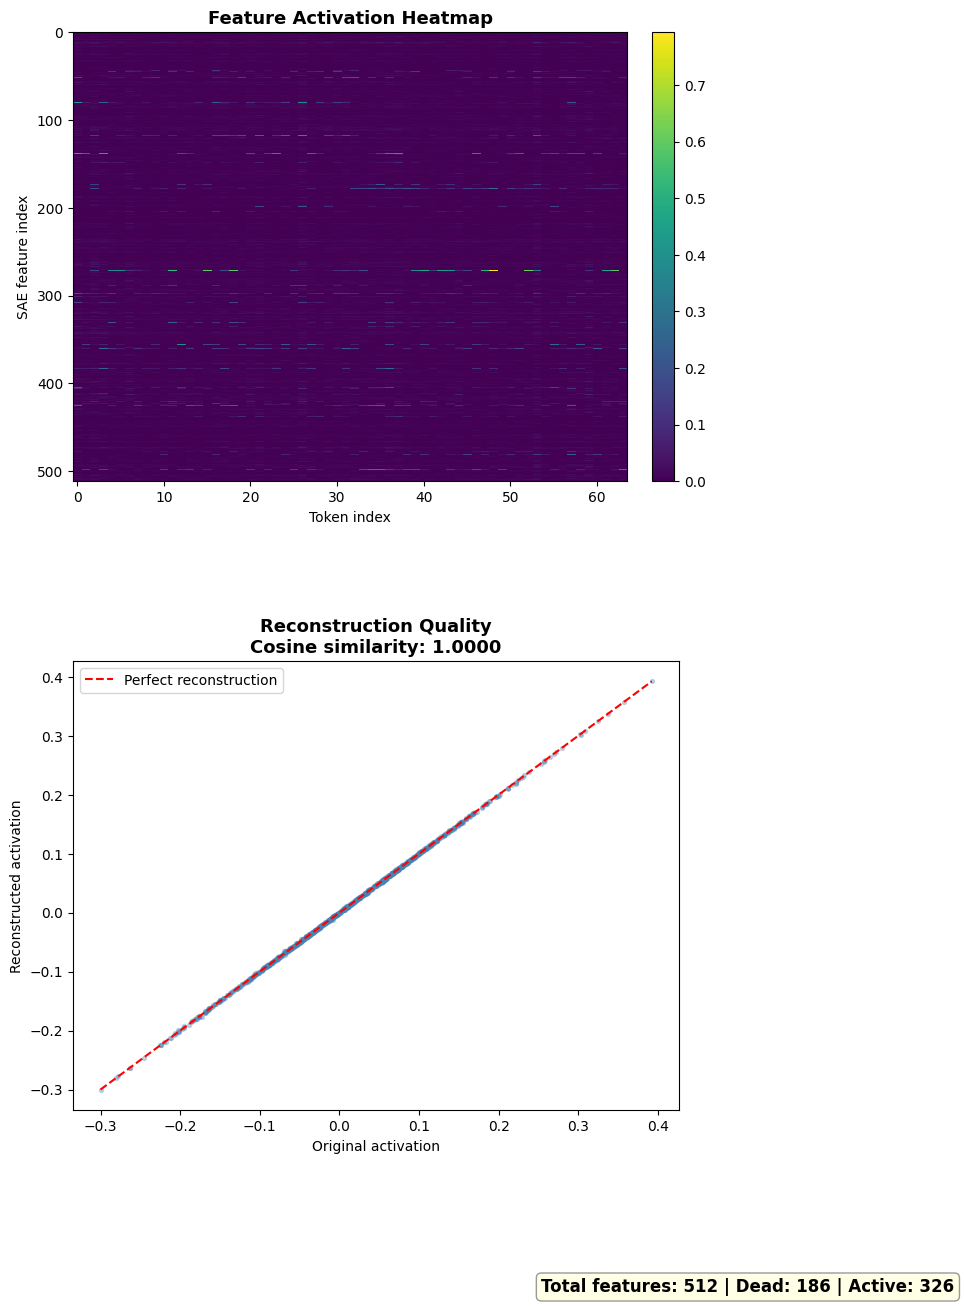

In [14]:
with torch.no_grad():
    sample = activations[:512].to(DEVICE)
    recon, features, l2, l1 = sae(sample)
    features_np = features.cpu().numpy()
    sample_np = sample.cpu().numpy()
    recon_np = recon.cpu().numpy()

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
heatmap_data = features_np[:64, :] 
im = ax1.imshow(heatmap_data.T, aspect='auto', cmap='viridis', interpolation='nearest')
ax1.set_title('Feature Activation Heatmap', fontsize=13, fontweight='bold')
ax1.set_xlabel('Token index')
ax1.set_ylabel('SAE feature index')
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)


ax3 = fig.add_subplot(gs[1, 0])
idx = np.random.choice(sample_np.size, size=1000, replace=False)
flat_input = sample_np.flatten()[idx]
flat_recon = recon_np.flatten()[idx]

ax3.scatter(flat_input, flat_recon, alpha=0.3, s=8, color='steelblue')
lims = [min(flat_input.min(), flat_recon.min()),
        max(flat_input.max(), flat_recon.max())]
ax3.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect reconstruction')
cos_sim = float(torch.nn.functional.cosine_similarity(recon, sample).mean())
ax3.set_title(f'Reconstruction Quality\nCosine similarity: {cos_sim:.4f}', 
              fontsize=13, fontweight='bold')
ax3.set_xlabel('Original activation')
ax3.set_ylabel('Reconstructed activation')
ax3.legend()

feature_freq = (features_np > 0).mean(axis=0) 
n_dead = (feature_freq == 0).sum()
n_common = (feature_freq >= 0.01).sum()



fig.text(0.5, -0.02, 
         f'Total features: {len(feature_freq)} | Dead: {n_dead} | Active: {n_common}',
         ha='center', fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

